# Linear Regression with one variableon real data

In this exercise, we are trying to determine which city is most suitable to open a new branch of a restaurant franchise. 
I am trying to solve the practices of *Andrew Ng*'s *Machine learning specialization* course, so the data and some of the packages are from that resource.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
import copy
import math
%matplotlib inline

In [8]:
# load_data() is a function of utils library designed by the instructor
x_train, y_train = load_data()
# view the data
print("training data type:",type(x_train))
print("First five elements of x_train are:\n", x_train[:5])
# view target values
print("target value type:",type(y_train))
print("First five elements of y_train are:\n", y_train[:5]) 

training data type: <class 'numpy.ndarray'>
First five elements of x_train are:
 [6.1101 5.5277 8.5186 7.0032 5.8598]
target value type: <class 'numpy.ndarray'>
First five elements of y_train are:
 [17.592   9.1302 13.662  11.854   6.8233]


This dataset consists of each cities population times 10k. For instance, the second city has a population of 55,277 people. Similarly y_train represents the monthly revenue of the restaurant in each city in units of $10k.

### Dimensionality
It is imensely important to check out the dimensions of your data. As you might already know, datasets are presented in form of matrixes. We may adjust the matrix to our needs, but while we're creating the algorithm from scratch, it is essential to set the dimensions correctly so we don't face errors. We will discuss this further, but if need to understand the math more, check out my [linear algebra repository](https://github.com/mohammadkhoubrou/Linear-Algebra-with-NumPy) Here's how you can check the dimension of your data and targets.

In [9]:
print ('The shape of x_train is:', x_train.shape)
print ('The shape of y_train is: ', y_train.shape)
print ('Number of training examples (m):', len(x_train))

The shape of x_train is: (97,)
The shape of y_train is:  (97,)
Number of training examples (m): 97


Did you notice that for each instance, there's a target value?

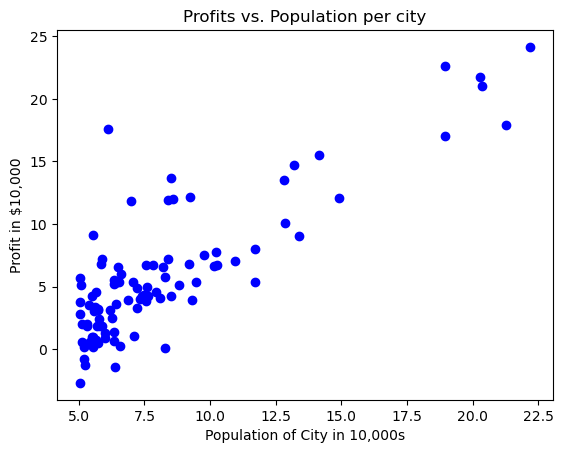

In [10]:
''' Data Visualization '''
plt.scatter(x_train, y_train, marker='o', c='b') 

# title
plt.title("Profits vs. Population per city")
# Set the y-axis label
plt.ylabel('Profit in $10,000')
# Set the x-axis label
plt.xlabel('Population of City in 10,000s')
plt.show()

In [11]:
def f(x, w, b):
    return w * x + b

In [12]:
def cost(x, y, w, b):
    m = x.shape[0]
    cost = 0

    for i in range(m):
        f_data = f(x[i] , w, b)
        cost = cost + (f_data - y[i])**2
    total_cost = 1/(2 * m) * cost

    return total_cost

In [13]:
def gradient(x,y,w,b):
    m = x.shape[0]
    dj_w = 0
    dj_b = 0

    for i in range(m):
        f_data = f(x[i] , w, b)
        dj_w_i = (f_data - y[i]) * x [i]
        dj_b_i = f_data - y[i]
        dj_w += dj_w_i
        dj_b += dj_b_i
    dj_w = dj_w / m
    dj_b = dj_b / m

    return dj_w , dj_b

In [14]:
def gradient_descent(x, y, w_init, b_init, alpha, num_iterations, cost_func, gradient_func):
    '''
    #Input
    x: input vector of learning instances
    y: labels or target values
    w_init: initial value of weights
    b_init: initial value of bias
    alpha: learning rate
    num_iterations: we specify the number of times the algorithm goes through data
    cost_func: the function we will use to calculate the cost
    gradient_func: the function to calculate the gradient at any point
    
    ##Output 
    w: final weight values using which we found the minimum cost
    b: final bias value
    J: sequence of cost values calculated during the training
    P: sequence of parameters that were altered during the training
    '''
    w = copy.deepcopy(w_init)
    b = b_init
    J = []
    P = []
    w = w_init

    for i in range(num_iterations):
        dj_w, dj_b = gradient_func(x, y, w, b)

        w = w - alpha * dj_w
        b = b - alpha * dj_b

        if i < 100000:
            J.append(cost_func(x, y, w, b))
            P.append([w, b])
        if i% math.ceil(num_iterations/10) == 0: #print the result of cost, gradient and parameters at every 1000 iterations
            print(f"Iteration {i:4}: Cost {J[-1]:0.2e} ",
            f"dj_dw: {dj_w: 0.3e}, dj_db: {dj_b: 0.3e}  ",
            f"w: {w: 0.3e}, b:{b: 0.5e}")

    return w, b, J, P

In [18]:
# initialize fitting parameters. Recall that the shape of w is (n,)
initial_w = 0.
initial_b = 0.

# some gradient descent settings
iterations = 1500
alpha = 0.01

w,b,J,P = gradient_descent(x_train ,y_train, initial_w, initial_b, 
                    alpha, iterations, cost, gradient)
print("w,b found by gradient descent:", w, b)

Iteration    0: Cost 6.74e+00  dj_dw: -6.533e+01, dj_db: -5.839e+00   w:  6.533e-01, b: 5.83914e-02
Iteration  150: Cost 5.31e+00  dj_dw: -5.492e-02, dj_db:  5.467e-01   w:  8.889e-01, b:-8.68345e-01
Iteration  300: Cost 4.96e+00  dj_dw: -4.190e-02, dj_db:  4.171e-01   w:  9.610e-01, b:-1.58616e+00
Iteration  450: Cost 4.76e+00  dj_dw: -3.197e-02, dj_db:  3.182e-01   w:  1.016e+00, b:-2.13378e+00
Iteration  600: Cost 4.64e+00  dj_dw: -2.439e-02, dj_db:  2.427e-01   w:  1.058e+00, b:-2.55156e+00
Iteration  750: Cost 4.57e+00  dj_dw: -1.860e-02, dj_db:  1.852e-01   w:  1.090e+00, b:-2.87028e+00
Iteration  900: Cost 4.53e+00  dj_dw: -1.419e-02, dj_db:  1.413e-01   w:  1.114e+00, b:-3.11343e+00
Iteration 1050: Cost 4.51e+00  dj_dw: -1.083e-02, dj_db:  1.078e-01   w:  1.133e+00, b:-3.29893e+00
Iteration 1200: Cost 4.50e+00  dj_dw: -8.261e-03, dj_db:  8.223e-02   w:  1.147e+00, b:-3.44044e+00
Iteration 1350: Cost 4.49e+00  dj_dw: -6.302e-03, dj_db:  6.273e-02   w:  1.158e+00, b:-3.54841e+00


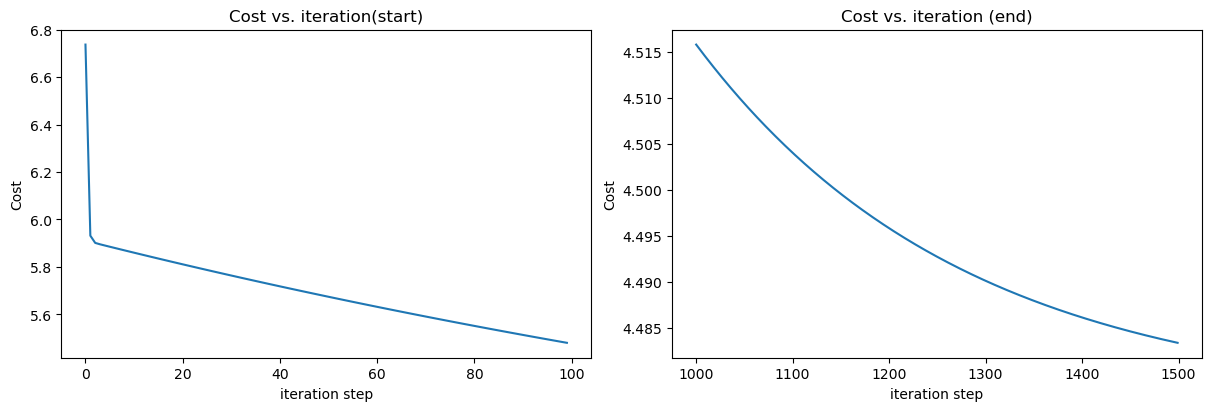

In [19]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J[:100])
ax2.plot(1000 + np.arange(len(J[1000:])), J[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()

In [20]:
m = x_train.shape[0]
predicted = np.zeros(m)

for i in range(m):
    predicted[i] = w * x_train[i] + b

Text(0.5, 0, 'Population')

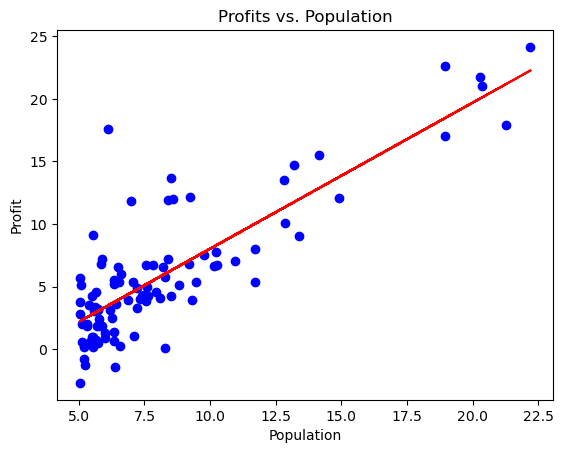

In [23]:
# plot our model
plt.plot(x_train, predicted, c = "r")

# plot the data points same as before 
plt.scatter(x_train, y_train, marker='o', c='b') 

# prepare the graph
plt.title("Profits vs. Population")
plt.ylabel('Profit')
plt.xlabel('Population')

As you can see on the graph, the red line which represents our model, predicts the target pretty well.